# 1qb-DB — deterministic benchmarking of the optimized $X(\pi)$

Repeat the gate pair $XX$ for $n$ cycles, inject a multiplicative amplitude error
$\epsilon$, read the survival probability $P_0(n)$. The sequence amplifies the
**coherent** part of the gate error by $2n$ — the part $C_3$ claims to remove — and
therefore turns a $5\times10^{-7}$ single-gate infidelity into something a laboratory
can actually see.

Read `README.md` first. Two things it says that this notebook assumes throughout:

* only the component of the error-curve closure **along the rotation axis** survives the
  $XX$ pair, doubled: $\theta_{\rm cycle}=2\epsilon\,|\hat n\cdot\mathbf R(T)|$;
* calibration is fitted **once at $\delta_z=\epsilon=0$ and frozen**; the injected
  $\epsilon$ multiplies the *calibrated* amplitude.

Kernel: **Python (curve)**. Run from this directory.

## 0. The gate under test is a Z-equivalence class — and why the $XX$ pair doesn't care

Every optimized arm was solved under the hard gate constraint
$W = R_z(\phi_{\rm vz})\,U_{\rm target}$ with $\phi_{\rm vz}$ a **free optimization
variable** ($W$ = coherent part of the three-level qubit block, by polar decomposition,
`_plan_full_cost.md` §2.3a). The target is therefore not the single matrix $X$ but the
whole family $\{R_z(\phi)\,X\}$: the leftover $Z$ rotation is a *virtual Z* — a software
frame update, free and error-free in hardware — and forcing $\phi_{\rm vz}=0$ would spend
real pulse resources on something software does for free.

Measured on the played waveforms at $\epsilon=\delta_z=0$, no calibration
(polar decomposition of `three_level_gate(arm)`'s qubit block, global phase modded out):

| arm | $\phi_{\rm vz}$ [rad] | $1-F$ vs bare $X$ | $\lVert W-R_z(\phi_{\rm vz})X\rVert$ | residual angle of the pair $W^2$ [rad] |
|---|---|---|---|---|
| A | 0 (frozen) | 1.7e-3 | 7.2e-2 | 7.8e-3 |
| B | +0.134 | 3.0e-3 | 4.7e-3 | 1.3e-2 |
| C | −0.056 | 5.3e-4 | 4.2e-4 | 4.5e-4 |
| D | +1.928 | 4.5e-1 | 1.2e-3 | 3.8e-4 |
| E | +2.861 | 6.5e-1 | 3.6e-4 | 3.7e-4 |

Two consequences for this experiment:

1. **The DB pair cancels $\phi_{\rm vz}$ identically — no calibration involved.** For a
   $\pi$ rotation, $X\,R_z(\phi)=R_z(-\phi)\,X$, so $(R_z(\phi)X)^2=X^2$: the virtual-Z
   phases of the two gates in a cycle cancel pairwise. Arms D/E are the extreme
   demonstration — as *raw* single gates they are nowhere near $X$
   ($1-F\approx0.45/0.65$, $\phi_{\rm vz}$ of order a radian), yet their gate pair is
   identity to a $\sim4\times10^{-4}$ rotation angle. The sequence therefore probes the
   *genuine* coherent error, never the gauge phase.
2. **What survives the pair is the error component along the rotation axis, doubled.**
   The $z$-part of each gate's residual flips sign under conjugation by $X$ and cancels;
   the $x$-part adds. Arm A shows both at once: its single-gate deviation from
   $R_z(\phi_{\rm vz})X$ is $7.2\times10^{-2}$ (mostly a $z$-axis error the plain
   Gaussian cannot null), but its pair residual is only $7.8\times10^{-3}$ — twice its
   $x$-component. This is the axial-projection statement
   $\theta_{\rm cycle}=2\epsilon\,|\hat n\cdot\mathbf R(T)|$ of `README.md` §0, seen
   directly at the propagator level.

Caveat before reusing this logic elsewhere: the cancellation is special to $\pi$
rotations. For $X_{90}$ the $Z$ freedom is two-sided,
$W=R_z(\alpha)\,U_{\rm target}\,R_z(\beta)$, it does not commute through the pair, and
must instead be absorbed by standard virtual-Z frame tracking.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import dblib as db

print(f"gate        {db.SPECS[db.GATE_KEY].name}")
print(f"T           {db.T} ns   (identical for every arm -- README section 2.1)")
print(f"played grid {db.N_PLAY} samples at {db.DEV.sample_rate} GS/s")
print(f"cycles      {db.N_CYCLES}  ->  {2 * db.N_CYCLES} gates, "
      f"{2 * db.N_CYCLES * db.T / 1e3:.1f} us")
print(f"test eps    +-{db.TEST_EPS:.0%}   (design eps = {db.DEV.control_error:.0%}, a "
      f"different quantity)")
print(f"decoherence {db.DEV.decoherence_floor:.4e} per gate, waveform independent")

gate        X(pi)
T           50.0 ns   (identical for every arm -- README section 2.1)
played grid 120 samples at 2.4 GS/s
cycles      60  ->  120 gates, 6.0 us
test eps    +-3%   (design eps = 2%, a different quantity)
decoherence 4.1667e-04 per gate, waveform independent


---
## 1. Arms and calibration

Arms come from `proposals/_gatelib`, so every number below is term-for-term comparable
with the single-gate proposal's Table 1. `ARM_ORDER` is decided by which `_runs/`
directories exist — a gate whose C/D/E are unsolved loads A and B alone and the whole
notebook still runs.

In [2]:
lab = db.load_arms()
{k: (a.name, a.layer, a.run_id, f"peak/Omega_max = {a.peak / db.DEV.rabi_max_rate:.1%}")
 for k, a in lab.arms.items()}

{'A': ('Gaussian', 'planar', None, 'peak/Omega_max = 48.2%'),
 'B': ('Gaussian + DRAG', 'planar_drag', None, 'peak/Omega_max = 48.2%'),
 'C': ('Optimized (3D)',
  'general',
  '20260808_F06min_gaussian3d_construction',
  'peak/Omega_max = 92.9%'),
 'D': ('Opt + fluence cap',
  'general',
  '20260810_F06b_fluence_cap2_mi20000',
  'peak/Omega_max = 52.7%'),
 'E': ('Opt AD-exact',
  'general',
  '20260810_F06e_adexact_construction_r2',
  'peak/Omega_max = 62.6%'),
 'F': ('Opt AD-robust',
  'general',
  '20260808_F06f_adrobust_construction',
  'peak/Omega_max = 93.5%')}

### Table 1 — calibration

Default protocol: **virtual Z only**. Arms B–E are exact three-level $X(\pi)$ by
construction, so nothing else has anything to find; §4 checks that claim with the full
laboratory knob set.

`vz-phi_vz` must be $\approx 0$: the DB frame phase equals the single-gate proposal's
frozen $\Phi_{\rm vz}$ (see `dblib.frame_rotation`'s sign note — the ladder rotation's
qubit block is $R_z(-f)$, which flips the sign twice). The residual is the played-grid
vs. design-grid sampling loss, not a calibration failure.

In [3]:
cals = db.print_calibration(lab)

calibration knobs: frame_phase   (fitted once at delta_z = eps = 0, then frozen)
arm waveform               scale  d_cal[MHz]  virtual Z  rot.err before      after        1-F         P2  vz-phi_vz
-------------------------------------------------------------------------------------------------------------------
A   Gaussian             1.00000      0.0000    0.00000       1.712e-03  1.712e-03  1.718e-03  9.573e-06  -2.02e-08
B   Gaussian + DRAG      1.00000      0.0000    0.13439       7.228e-06  7.228e-06  7.231e-06  4.199e-09  -5.80e-05
C   Optimized (3D)       1.00000      0.0000   -0.05629       6.443e-08  6.443e-08  1.729e-04  5.078e-04   7.71e-05
D   Opt + fluence cap    1.00000      0.0000    1.92990       8.503e-09  8.503e-09  8.487e-06  1.576e-05   1.63e-03
E   Opt AD-exact         1.00000      0.0000   -2.87063       7.816e-07  7.816e-07  8.382e-07  1.454e-07   4.87e-03
F   Opt AD-robust        1.00000      0.0000   -1.49575       1.013e-09  1.013e-09  5.981e-06  5.134e-06   

### Fig. 1 — the played waveforms

The $120$-sample AWG grid, markers on: the sampling is part of what is being compared.

**The two quadratures carry fixed colours, not the arm colour** — they are different
physical channels and have to read the same way in every panel:

* **$\Omega_x$** (dark blue) — the drive the gate is built from;
* **$\Omega_y$** (red) — the DRAG/Stark correction supplied by the readout map.
  Identically zero on the `planar` layer (arm A, noted in its title); plotted anyway,
  because the flat line is what makes B's correction legible as a *difference* from A.

The dotted grey lines are the hardware ceiling $\pm\Omega_{\max}$, not data. Arm identity
is in the panel title; the arm colours are used in Figs. 2-4, where several arms share
one axis.

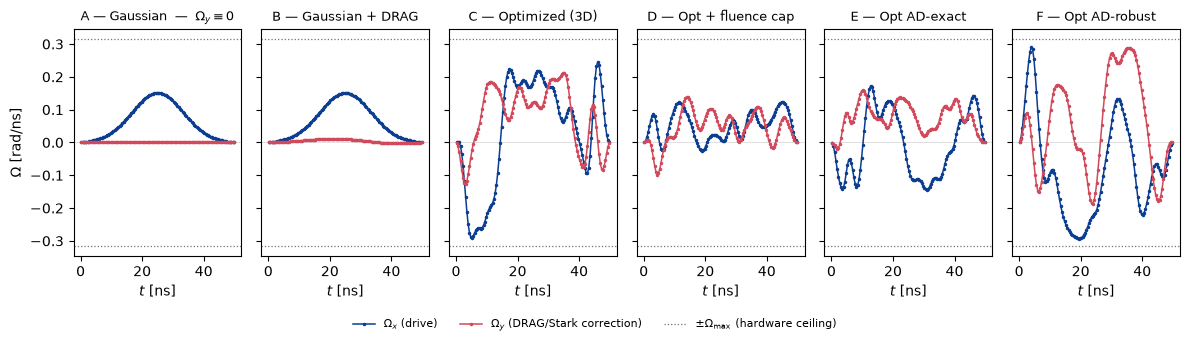

In [4]:
fig = db.plot_played_waveforms(lab)

### ★ Both channels, axially projected

The echo argument never used the fact that $\mathbf R$ came from the amplitude error.
It applies verbatim to the quasi-static $Z$ channel, whose first-order error curve is
the design curve $\mathbf r(t)$ itself. A single-gate infidelity weights the *full*
closure isotropically ($C_1 = w_1|\mathbf r(T)|^2$, and $\delta_z/2\pi = 0.1$ MHz makes
$w_1$ small), so an optimizer can leave the $Z$ curve wide open for almost nothing — but
the sequence amplifies its **axial** part by $2n$ just the same.

Read this table before the traces: it says which channel each arm's trace is reporting
on. `Z/amp > 1` means the DB experiment, as specified, is not measuring the amplitude
error for that arm.

In [5]:
axial = db.print_axial_table(lab)

axial (echo-surviving) closure of both channels, at eps = 3% and delta_z/2pi = 0.1 MHz
arm waveform               |R_amp|   |n.R_amp|   angle/cyc  |R_z| [ns]  |n.R_z| [ns]   angle/cyc    Z/amp
---------------------------------------------------------------------------------------------------------
A   Gaussian                3.1416      3.1416  1.8850e-01     17.2432        0.0000  0.0000e+00     0.00
B   Gaussian + DRAG         3.1531      3.1300  1.8780e-01     17.1510        0.1536  1.9305e-04     0.00
C   Optimized (3D)          5.0662      0.5587  3.3523e-02      2.4609        1.8397  2.3118e-03     0.07
D   Opt + fluence cap       3.0327      1.2273  7.3639e-02     26.8125       21.0314  2.6429e-02     0.36
E   Opt AD-exact            1.7967      0.2215  1.3287e-02     23.7491       23.6541  2.9725e-02     2.24
F   Opt AD-robust           0.2433      0.1779  1.0674e-02      5.2255        5.1413  6.4608e-03     0.61
Z/amp > 1 means the DB trace is reporting the quasi-static Z chan

---
## 3. Predicted vs. measured per-cycle angle

The experiment's whole logic in six columns.

`predicted` $=2\epsilon|\hat n\cdot\mathbf R(T)|$ is a property of the **design** — a
two-level curve integral. `measured` is a property of the **device** — a three-level
propagation at finite $\epsilon$, with leakage polar-divided out.

Novera measured a ratio of $\sim10^2$ for every waveform designed to be robust, because
$\epsilon$ also rescales the Stark shift $\Omega^2/4|\Delta|$ and the drive-frequency
knob cancels that only at $\epsilon=0$; that residual is first order in $\epsilon$
however well the curve closes. Arms C/D/E were optimized against the three-level model,
so the ratio here is a genuine open question. **A large ratio is a result.**

In [6]:
angles = db.print_gate_table(lab, calibrations=cals)

per-cycle rotation error at eps = +3.0% (one cycle = the XX pair)
arm waveform                 |R(T)|    |n.R(T)|   predicted  measured +  measured -     ratio  n to pi/2
--------------------------------------------------------------------------------------------------------
A   Gaussian             3.1416e+00  3.1416e+00  1.8850e-01  1.7998e-01  1.9558e-01      1.04        8.0
B   Gaussian + DRAG      3.1531e+00  3.1300e+00  1.8780e-01  2.0124e-01  1.7496e-01      1.07        7.8
C   Optimized (3D)       5.0662e+00  5.5872e-01  3.3523e-02  3.9346e-03  2.0385e-02      0.61       77.1
D   Opt + fluence cap    3.0327e+00  1.2273e+00  7.3639e-02  6.8456e-02  7.2894e-02      0.99       21.5
E   Opt AD-exact         1.7967e+00  2.2146e-01  1.3287e-02  2.5099e-02  2.0757e-02      1.89       62.6
F   Opt AD-robust        2.4332e-01  1.7790e-01  1.0674e-02  6.5239e-03  6.6655e-03      0.62      235.7
predicted = 2 eps |n . R(T)|, the first-order two-level estimate; only the
component along the

---
## 4. The DB sequence

One gate is compressed into a single $9\times9$ channel, so $n$ cycles is a matrix power
$(\Lambda^2)^n$ rather than a re-integration. The virtual Z sits inside $\Lambda$ as a
left multiplication, and $(ZU)^n$ is exactly what an instrument does when it shifts the
phase of every subsequent drive — §5 check 3 verifies that against a genuinely
re-integrated sequence.

★ **Three configurations, all of them real: $\epsilon=0$, $+\epsilon$, $-\epsilon$, with
the full error model on throughout.** An earlier draft carried a second family
(`coherent`) with $T_1/T_2$ and $\delta_z$ deleted from the Hamiltonian, following
Novera, to "isolate the control-error signal". That is gone. No instrument has a knob
that switches $T_1$ off, so a number read off such a run is not a measurement and must
not sit in a results table beside ones that are.

The separation it was doing is done instead by **subtraction**: an experiment runs the
same sequence once without the deliberate amplitude error and differences the two
traces. That is what every entry of `db_readout` is.

In [7]:
traces = db.db_traces(lab, cycles=db.N_CYCLES, eps=db.TEST_EPS, calibrations=cals)
readouts = db.print_db_table(lab, traces)

DB readout after 60 XX cycles (120 gates, 6.00 us) at eps = +-3%
arm waveform             envelope loss  signal at N   max signal    n@5%   Delta P0      P2(N)
----------------------------------------------------------------------------------------------
A   Gaussian                 1.335e-01    5.260e-01    9.649e-01       3  9.849e-01   1.20e-04
B   Gaussian + DRAG          1.309e-01    5.117e-01    9.667e-01       3  9.865e-01   1.04e-04
C   Optimized (3D)           5.678e-02    2.726e-01    2.726e-01      25  3.294e-01   7.78e-03
D   Opt + fluence cap        5.461e-01    4.926e-01    7.959e-01       5  9.733e-01   2.29e-04
E   Opt AD-exact             6.077e-01    5.382e-01    5.382e-01      11  9.509e-01   3.41e-04
F   Opt AD-robust            4.784e-02    3.738e-02    3.738e-02       -  8.522e-02   1.17e-03

Full error model in every column -- no term is ever switched off.
envelope loss = 1 - P0(N) of the eps = 0 reference run;
signal at N   = |P0(N,+-eps) - P0(N,0)|, the discrim

### Fig. 4 — which channel is the trace reporting? (a real knob)

$P_0$ has collapsed for several arms. Attributing that collapse is the natural next
question, and the tempting way to answer it is to rerun with $\delta_z$ deleted and
compare — but that is a statement about a model, not about a device.

**A drive frequency is a knob.** Detuning it on purpose adds to the unknown static
offset, so sweeping it measures the same thing an experiment can actually measure. Two
readings come out of one scan:

* **left** — $P_0(N)$ of the $\epsilon=0$ reference vs. applied detuning: how fast the
  sequence loses $P_0$ to a frequency error alone. A curve that falls away steeply from
  the nominal point is an arm whose $|\hat n\cdot\mathbf r(T)|$ is large, i.e. whose
  $Z$-noise closure the $XX$ echo does not remove — §2's `axial_table` predicts the
  curvature;
* **right** — the DB signal at $\pm\epsilon$ vs. the same axis: whether the
  amplitude-error discriminator survives once the drive is off resonance. Where this is
  flat, the reading at the nominal point is about $\epsilon$; where it is not, the two
  channels are entangled at that working point.

This costs ~40 s (7 detunings × 3 runs × 5 arms).

drive-frequency scan over -0.50 .. +0.50 MHz in 41 steps (60 XX cycles, full model)
arm waveform             P0 nominal   df to P0<0.5  signal nom.  signal min  signal max
---------------------------------------------------------------------------------------
A   Gaussian                 0.8665        > range       0.9649      0.9582      0.9685
B   Gaussian + DRAG          0.8691      0.449 MHz       0.9667      0.9329      0.9710
C   Optimized (3D)           0.9432      0.450 MHz       0.2726      0.1439      0.8192
D   Opt + fluence cap        0.4539     at nominal       0.7959      0.7223      0.9343
E   Opt AD-exact             0.3923     at nominal       0.5382      0.4212      0.6815
F   Opt AD-robust            0.9522        > range       0.0374      0.0324      0.0423

P0 nominal     = P0(N) of the eps = 0 reference at the nominal drive frequency;
df to P0<0.5   = how far the drive may be detuned before the reference falls below 0.5
                 ('> range' = never, within 

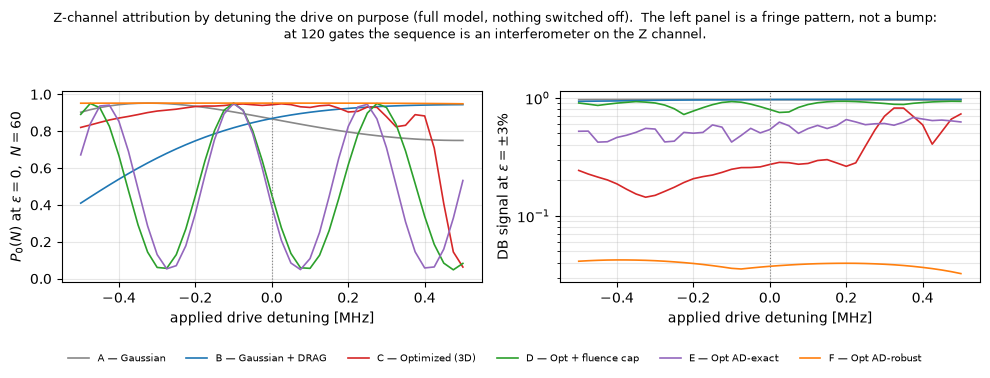

In [8]:
scan_det = db.print_detuning_scan(lab, calibrations=cals)
fig = db.plot_detuning_scan(lab, scan_det)

### Fig. 3 — $P_0(n)$

**The grey dashed line is the $\epsilon=0$ reference run** — the same sequence on the
same device without the deliberate amplitude error, which is something an experiment
simply does. It is what the coloured curves are read *against*, never a result on its
own. On a transmon it is not flat: decoherence, the static detuning and accumulated
leakage all pull it down whether or not the control is robust. The vertical gap between
it and the coloured curves is the part that is about $\epsilon$.

Reading the raw $P_0$ instead of the gap would credit an arm for decay it cannot
control — which is why `envelope_loss` and `signal` are reported as two separate
numbers rather than folded into one $\Delta P_0$.

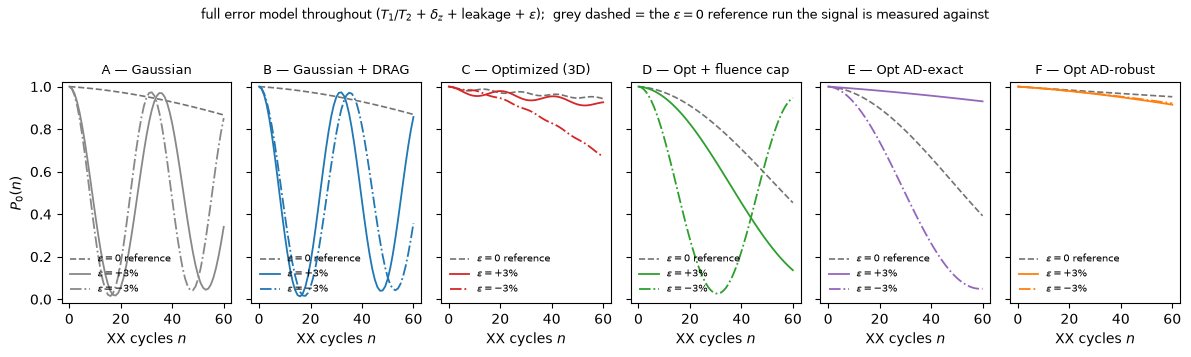

In [9]:
fig = db.plot_db_traces(lab, traces)

### Fig. 5 — signal vs. injected error

$\max_n|P_0(n,\epsilon)-P_0(n,0)|$ — the same quantity the table reports, as a function
of the error the sequence is meant to detect. Full model throughout.

★ Keep the negative $\epsilon$: $C_3$ is even in $\epsilon$ to leading order, so any
asymmetry between $\pm\epsilon$ reads out the odd higher-order channel. That asymmetry
is a result, not noise.

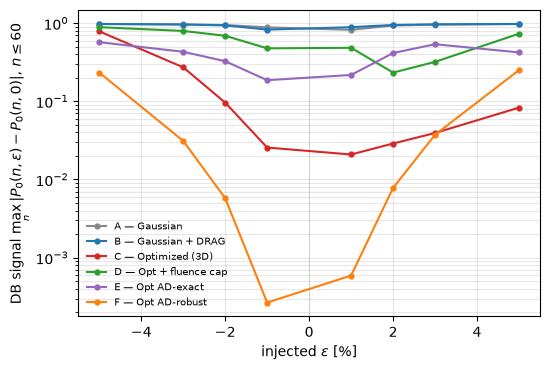

In [10]:
scan = db.signal_vs_epsilon(lab, calibrations=cals)
fig = db.plot_signal_vs_epsilon(lab, scan)

---
## 5. Validation

Right first, then accurate. Checks 1, 2 and 4 are cheap and run below; check 3
(grid convergence) re-solves every arm on finer grids and is opt-in.

In [11]:
checks = db.run_all_checks(lab, cals)

[PASS] coherent_limit
        {'max_abs_diff': {'A': 4.663207507882296e-15, 'B': 8.215656632889435e-15, 'C': 4.560816494360807e-15, 'D': 2.5894628196555746e-15, 'E': 3.996835399707673e-15, 'F': 3.666352090552496e-15}, 'pass': True, 'tol': 1e-10}
[PASS] expm_backends
        {'max_abs_diff': {'A': 2.7755840503260343e-15, 'B': 4.7739655430314266e-15, 'C': 2.434909185329438e-15, 'D': 4.219004771288056e-15, 'E': 4.2227543306980735e-15, 'F': 2.135556627277529e-15}, 'pass': True, 'tol': 1e-12}
[PASS] sequence_composition
        {'cycles': 3, 'rows': {'A': {'p0_matrix_power': 0.997232401537854, 'p0_concatenated': 0.9972324015378559, 'abs_diff': 1.887379141862766e-15}, 'B': {'p0_matrix_power': 0.9972635908234007, 'p0_concatenated': 0.9972635908234018, 'abs_diff': 1.1102230246251565e-15}, 'C': {'p0_matrix_power': 0.992106126293525, 'p0_concatenated': 0.9921061262935263, 'abs_diff': 1.3322676295501878e-15}, 'D': {'p0_matrix_power': 0.9957680289763815, 'p0_concatenated': 0.9957680289763852, 'abs

In [12]:
RUN_GRID_CHECK = False   # ~1-2 minutes: re-broadcasts and re-runs every arm at N = 120/240/600

if RUN_GRID_CHECK:
    grid = db.check_grid_convergence(lab)
    for n_grid, row in grid["max_signal"].items():
        print(f"N = {n_grid:4d}  " + "  ".join(f"{k}: {v:.4e}" for k, v in row.items()))
    print("\nrelative change, played (120) vs finest:")
    print({k: f"{v:.2%}" for k, v in grid["rel_change"].items()})

---
## 6. Readout

Fill this in after the first run. The four questions it has to answer:

1. **Which channel is each trace reporting?** Fig. 4's left panel is the test. An arm
   whose reference curve is sharply peaked at the nominal detuning is being read out on
   the $Z$ channel, not the amplitude one, and its `signal` column is not the number the
   protocol claims. If that is where the good arms land, the headline belongs on the
   detuning-resolved figure, not on a single working point.
2. **Does the ordering of `signal` follow the ordering of $|\hat n\cdot\mathbf R(T)|$?**
   If yes, the design geometry predicts the amplified experiment and the budget framework
   has a laboratory-visible consequence. If no, §3's ratio column says where it broke.
3. **Is `n@5%` resolvable at 60 cycles?** `-` for an arm means the sequence never
   resolved its error at this length — a result, not a missing number. If several arms
   come back `-`, lengthen the sequence until decoherence, not the control error, is the
   limit, and report that crossover as the figure of merit.
4. **Is the $\pm\epsilon$ asymmetry in Fig. 5 significant?** A visible asymmetry means an
   odd-order channel the even $C_3$ term does not model.